In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
df=pd.read_csv("C:\\Users\\user\\Downloads\\Traffic.csv")
print(df)

             Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0     12:00:00 AM    10         Tuesday        31          0         4   
1     12:15:00 AM    10         Tuesday        49          0         3   
2     12:30:00 AM    10         Tuesday        46          0         3   
3     12:45:00 AM    10         Tuesday        51          0         2   
4      1:00:00 AM    10         Tuesday        57          6        15   
...           ...   ...             ...       ...        ...       ...   
2971  10:45:00 PM     9        Thursday        16          3         1   
2972  11:00:00 PM     9        Thursday        11          0         1   
2973  11:15:00 PM     9        Thursday        15          4         1   
2974  11:30:00 PM     9        Thursday        16          5         0   
2975  11:45:00 PM     9        Thursday        14          3         1   

      TruckCount  Total Traffic Situation  
0              4     39               low  
1              3     55

In [40]:
print(df)
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
print(df.isnull().sum())
df.drop(["Time"],axis=1,inplace=True)
print(df)

             Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0     12:00:00 AM    10         Tuesday        31          0         4   
1     12:15:00 AM    10         Tuesday        49          0         3   
2     12:30:00 AM    10         Tuesday        46          0         3   
3     12:45:00 AM    10         Tuesday        51          0         2   
4      1:00:00 AM    10         Tuesday        57          6        15   
...           ...   ...             ...       ...        ...       ...   
2971  10:45:00 PM     9        Thursday        16          3         1   
2972  11:00:00 PM     9        Thursday        11          0         1   
2973  11:15:00 PM     9        Thursday        15          4         1   
2974  11:30:00 PM     9        Thursday        16          5         0   
2975  11:45:00 PM     9        Thursday        14          3         1   

      TruckCount  Total Traffic Situation  
0              4     39               low  
1              3     55

In [41]:
c=LabelEncoder()
df["Day of the week"]=c.fit_transform(df["Day of the week"])
df["Traffic Situation"]=c.fit_transform(df["Traffic Situation"])
print(df)


      Date  Day of the week  CarCount  BikeCount  BusCount  TruckCount  Total  \
0       10                5        31          0         4           4     39   
1       10                5        49          0         3           3     55   
2       10                5        46          0         3           6     55   
3       10                5        51          0         2           5     58   
4       10                5        57          6        15          16     94   
...    ...              ...       ...        ...       ...         ...    ...   
2971     9                4        16          3         1          36     56   
2972     9                4        11          0         1          30     42   
2973     9                4        15          4         1          25     45   
2974     9                4        16          5         0          27     48   
2975     9                4        14          3         1          15     33   

      Traffic Situation  
0

In [42]:
x = df.drop(columns=["Traffic Situation"])
y = df["Traffic Situation"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(len(x_train))
print(len(y_train))

2380
2380


In [43]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:{:.2f}%".format(accuracy * 100))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("\nclassification report:\n", classification_report(y_test,y_pred))

Accuracy:73.49%
confusion matrix:
 [[119   2   0   6]
 [ 14  12   0  37]
 [  2   2  17  45]
 [ 33  12   5 290]]

classification report:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81       127
           1       0.43      0.19      0.26        63
           2       0.77      0.26      0.39        66
           3       0.77      0.85      0.81       340

    accuracy                           0.73       596
   macro avg       0.67      0.56      0.57       596
weighted avg       0.72      0.73      0.70       596



C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              Date  Day of the week     CarCount    BikeCount     BusCount  \
count  2976.000000      2976.000000  2976.000000  2976.000000  2976.000000   
mean     16.000000         3.193548    68.696573    14.917339    15.279570   
std       8.945775         2.007090    45.850693    12.847518    14.341986   
min       1.000000         0.000000     6.000000     0.000000     0.000000   
25%       8.000000         1.000000    19.000000     5.000000     1.000000   
50%      16.000000         3.000000    64.000000    12.000000    12.000000   
75%      24.000000         5.000000   107.000000    22.000000    25.000000   
max      31.000000         6.000000   180.000000    70.000000    50.000000   

        TruckCount        Total  Traffic Situation  
count  2976.000000  2976.000000        2976.000000  
mean     15.324933   114.218414           1.994624  
std      10.603833    60.190627           1.259307  
min       0.000000    21.000000           0.000000  
25%       6.000000    55.000000 

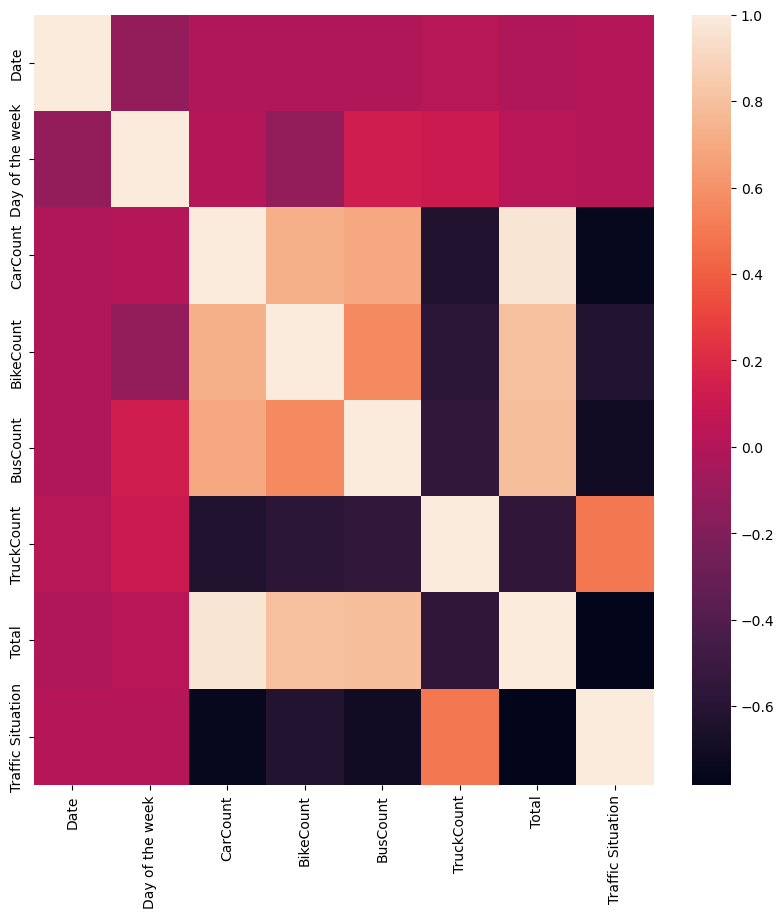

In [44]:
print(df.describe())
print(df.corr())
plt.figure(figsize=(10,10))
sns.heatmap(df.corr())
plt.show()